In [ ]:
# lib import
import os
import time
import torch
import numpy as np
from tqdm import tqdm
from datasets import load_dataset
from sentence_transformers import SentenceTransformer

# setup
ds_size = 1000000
source_ds_cache_dir = os.path.join(os.getcwd(), "data", "hf-source")

embed_models = [
    "all-MiniLM-L6-v2",
    "sentence-transformers/all-mpnet-base-v2",
    "nomic-ai/nomic-embed-text-v1.5"
    ]
embed_ds_dirnames = []
for name in embed_models:
    embed_ds_dirnames.append(name.split("/")[-1])

ds_pos_results = []

device = "cuda" if torch.cuda.is_available() else "cpu"
print("running on " + device)

# Acquiring the Source Dataset
Using Huggingface's Datasets we can easily load the wikipedia (20231101.en) dataset. Since we are focusing on encyclopedic data, this will serve as the base for testing the dataset generation pipeline.

In [ ]:
source_ds_cache_dir = os.path.join(os.getcwd(), "data", "hf-source")
ds = load_dataset("wikimedia/wikipedia", "20231101.en", cache_dir=source_ds_cache_dir)

In [ ]:
# verification (optional)
print(f"Dataset length: {len(ds['train'])}")
print(ds['train'][0])
print(ds['train'][-1])

In [ ]:
# create subset for dev
ds_shuffled = ds.shuffle(seed=97)
if ds_size > 0:
    ds_subset = ds_shuffled['train'].select(range(ds_size))
else:
    ds_subset = ds_shuffled['train']
    
print(f"Test subset length: {len(ds_subset)}")
print(f"Sample entry: {ds_subset[0]['title']}")

# Embedding Generation

In [ ]:
embed_ds = []
print("Preparing texts...")
texts = ds_subset['text']

for index, model_name in enumerate(embed_models):
    ds_embed_dir = os.path.join(os.getcwd(), "data", "ds_embed",  embed_ds_dirnames[index], str(ds_size))
    embed_ds.append(ds_subset)

    print("Loading model...")
    model = SentenceTransformer(model_name, trust_remote_code=True, device=device)
    tokenizer = model.tokenizer
    print("Tokenizer loaded:")
    print(tokenizer)
    
    print("Generating tokens in batches...")
    tokenization_start = time.time()
    batch_size = 10000
    total_samples = len(texts)
    all_token_ids = []

    for i in tqdm(range(0, total_samples, batch_size), desc="Tokenizing batches"):
        batch_texts = texts[i:i + batch_size]
        batch_encoding = tokenizer(
            batch_texts,
            padding=True,
            truncation=True, 
            return_tensors=None,
            add_special_tokens=True
        )
        all_token_ids.extend(batch_encoding['input_ids'])
    tokenization_time = time.time() - tokenization_start
    print(f"Tokenization took: {tokenization_time:.2f} second(s)")

    print("Adding raw token ids to embed dataset...")
    embed_ds[index] = embed_ds[index].add_column("token_ids", all_token_ids)

    print("Saving dataset with tokens...")
    embed_ds[index].save_to_disk(ds_embed_dir)

    print("Generating embeddings...")
    embedding_start = time.time()
    
    if(model_name == "nomic-ai/nomic-embed-text-v1.5"):
        batch_encoding = model.encode(texts, show_progress_bar=True, batch_size=1, device=device, prompt="clustering: ")
    else:
        batch_encoding = model.encode(texts, show_progress_bar=True, batch_size=32, device=device)

    embedding_time = time.time() - embedding_start
    print(f"Embedding generation took: {embedding_time:.2f} second(s)")
    
    embed_ds[index] = embed_ds[index].add_column("embeddings", batch_encoding.tolist())

    print("Saving dataset with embeddings...")
    embed_ds[index].save_to_disk(ds_embed_dir)

# Processing


In [ ]:
import numpy as np
from numpy import ndarray
from datasets import Dataset, DatasetDict
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA


def prep(data: Dataset | DatasetDict) -> ndarray:
    prep_start = time.time()
    
    # L2-normalization (to euclidean instead of cosine)
    embeddings_array = np.asarray(data, dtype=np.float32)
    embeddings_norm = normalize(embeddings_array, norm="l2", axis=1)

    # PCA red to 50 dims: De-noising and speedup
    pca = PCA(n_components=50, random_state=97, svd_solver="auto", whiten=False)
    data = pca.fit_transform(embeddings_norm)
    
    prep_time = time.time() - prep_start
    print(f"Data preparation took: {prep_time:.2f} seconds")
    
    return data

In [ ]:

from sklearn.preprocessing import MinMaxScaler

def normalize_coords(embed_reduced, target_range=(-1, 1)):
    scaler = MinMaxScaler(feature_range=target_range)
    return scaler.fit_transform(embed_reduced)

# Pipeline A (UMAP)
Based on [`knoto`](https://github.com/whatphilipcodes/knoto), this pipeline uses `UMAP` to reduce `sBERT` embeddings into two (spatial) dimensions.

In [ ]:
import umap
from datasets import load_from_disk

for dirname in embed_ds_dirnames:
    ds_embed_dir = os.path.join(os.getcwd(), "data", "ds_embed", dirname, str(ds_size))
    ds_pos_dir = os.path.join(os.getcwd(), "data", "ds_pos", dirname, "umap", str(ds_size))

    ds_embed = load_from_disk(ds_embed_dir)
    print(f"Loaded dataset with {len(ds_embed)} entries")

    # collect embeddings
    embeddings_array = prep(ds_embed['embeddings'])
    print(f"Embeddings shape: {embeddings_array.shape}")

    # apply UMAP reduction
    reducer = umap.UMAP(n_components=2, random_state=97, init="pca")
    print("Applying UMAP reduction...")
    reduction_start = time.time()
    embed_reduced = reducer.fit_transform(embeddings_array)
    print(f"2D embeddings shape: {embed_reduced.shape}")
    reduction_time = time.time() - reduction_start
    print(f"UMAP dimensionality reduction took: {reduction_time:.2f} second(s)")

    # apply normalization
    embed_reduced = normalize_coords(embed_reduced)

    # add to ds
    ds_pos = ds_embed.add_column("x", embed_reduced[:, 0].tolist())
    ds_pos = ds_pos.add_column("y", embed_reduced[:, 1].tolist())
    print(f"Final dataset columns: {ds_pos.column_names}")

    # save ds with positions
    ds_pos.save_to_disk(ds_pos_dir)
    ds_pos_results.append(ds_pos_dir)
    print("Dataset with UMAP positions saved successfully!")

# Pipeline B (t-SNE)
based on the `scikit-learn` implementation of `t-SNE`.

In [ ]:
from openTSNE import TSNE
from datasets import load_from_disk

for dirname in embed_ds_dirnames:
    ds_embed_dir = os.path.join(os.getcwd(), "data", "ds_embed", dirname, str(ds_size))
    ds_pos_dir = os.path.join(os.getcwd(), "data", "ds_pos", dirname, "tsne", str(ds_size))

    # load dataset with embeddings (reuse from UMAP pipeline)
    ds_embed = load_from_disk(ds_embed_dir)
    print(f"Loaded dataset with {len(ds_embed)} entries")

    # collect embeddings
    embeddings_array = prep(ds_embed['embeddings'])
    print(f"Embeddings shape: {embeddings_array.shape}")

    # apply t-SNE reduction using OpenTSNE
    tsne = TSNE(
        n_components=2, 
        random_state=97, 
        initialization="pca",
        n_jobs=-1  # use all available cores
    )
    print("Applying t-SNE reduction...")
    embed_reduced_tsne = tsne.fit(embeddings_array)
    print(f"2D t-SNE embeddings shape: {embed_reduced_tsne.shape}")

    # normalize coords
    embed_reduced_tsne = normalize_coords(embed_reduced_tsne)

    # add to dataset
    ds_pos_tsne = ds_embed.add_column("x", embed_reduced_tsne[:, 0].tolist())
    ds_pos_tsne = ds_pos_tsne.add_column("y", embed_reduced_tsne[:, 1].tolist())
    print(f"Final dataset columns: {ds_pos_tsne.column_names}")

    # save dataset with t-SNE positions
    ds_pos_tsne.save_to_disk(ds_pos_dir)
    ds_pos_results.append(ds_pos_dir)
    print("Dataset with t-SNE positions saved successfully!")

# Visualization

Loading data...


Loading dataset from disk:   0%|          | 0/17 [00:00<?, ?it/s]

Assigning cols...
Running kdplot()...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-MiniLM-L6-v2_tsne_1000000_20250911T153110.pdf


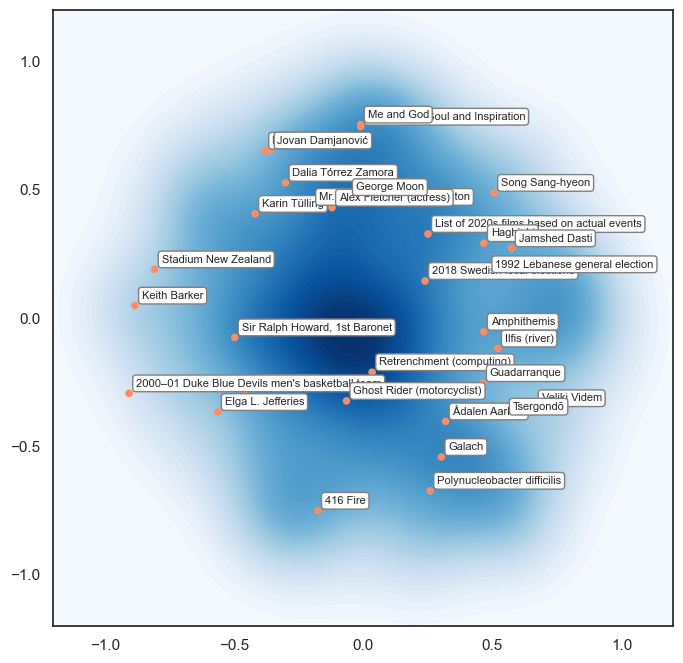

Loading data...


Loading dataset from disk:   0%|          | 0/25 [00:00<?, ?it/s]

Assigning cols...
Running kdplot()...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-mpnet-base-v2_tsne_1000000_20250911T153113.pdf


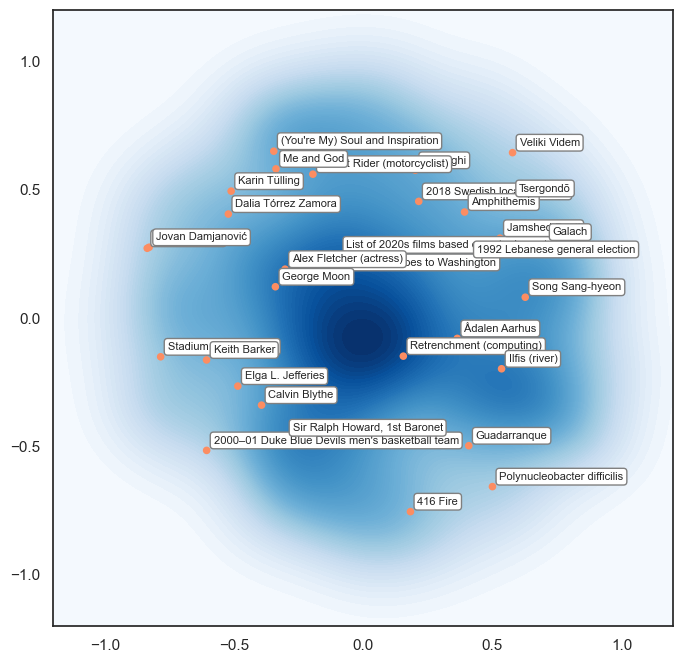

In [33]:
from datasets import load_from_disk
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from datetime import datetime

ds_pos_results = [os.path.join(os.getcwd(), "data", "ds_pos", "all-MiniLM-L6-v2", "tsne", str(1000000)), os.path.join(os.getcwd(), "data", "ds_pos", "all-mpnet-base-v2", "tsne", str(1000000))]

img_dir = os.path.join(os.getcwd(), "img")
os.makedirs(img_dir, exist_ok=True)

teaser_data = []

for dir in ds_pos_results:
    print("Loading data...")

    ds_src = load_from_disk(dir)
    ds_pos = ds_src.shuffle(seed=97).select(range(1000))
    # ds_pos = load_from_disk(dir)
    teaser_data.append(ds_pos)

    print("Assigning cols...")
    xs = ds_pos["x"]
    ys = ds_pos["y"]
    labels = ds_pos["title"]

    plt.figure(figsize=(8, 8))  # Square figure size
    sns.set_theme(style="white")

    random.seed(97)
    random_indices = set(random.sample(range(len(xs)), min(32, len(xs))))

    # Separate labeled and unlabeled points
    unlabeled_x = [x for i, x in enumerate(xs) if i not in random_indices]
    unlabeled_y = [y for i, y in enumerate(ys) if i not in random_indices]

    labeled_x = [x for i, x in enumerate(xs) if i in random_indices]
    labeled_y = [y for i, y in enumerate(ys) if i in random_indices]

    palette = sns.color_palette("Set2")

    print("Running kdplot()...")
    # KDE density plot for unlabeled points
    sns.kdeplot(
        x=unlabeled_x, y=unlabeled_y,
        fill=True,
        thresh=0,
        levels=100,
        cmap="Blues"
    )

    print("Running scatterplot()...")
    # Scatter for labeled points
    sns.scatterplot(x=labeled_x, y=labeled_y, s=30, color=palette[1], edgecolor='none', zorder=3)

    # Annotate labeled points
    for i, (x, y, label) in enumerate(zip(xs, ys, labels)):
        if i in random_indices:
            plt.annotate(
                label,
                (x, y),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=1.0, edgecolor='gray')
            )

    # Set fixed square aspect ratio and limits
    plt.xlim(-1.2, 1.2)
    plt.ylim(-1.2, 1.2)

    # Generate filename with timestamp
    timestamp = datetime.now().strftime("%Y%m%dT%H%M%S")
    dir_parts = dir.replace(os.getcwd(), "").strip(os.sep).split(os.sep)
    filename = f"{dir_parts[2]}_{dir_parts[3]}_{dir_parts[4]}_{timestamp}.pdf"
    filepath = os.path.join(img_dir, filename)

    # Save as PDF
    plt.savefig(filepath, format='pdf', bbox_inches='tight')
    print(f"Saved plot to: {filepath}")

    plt.show()


Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\teaser_20250911T155736.pdf


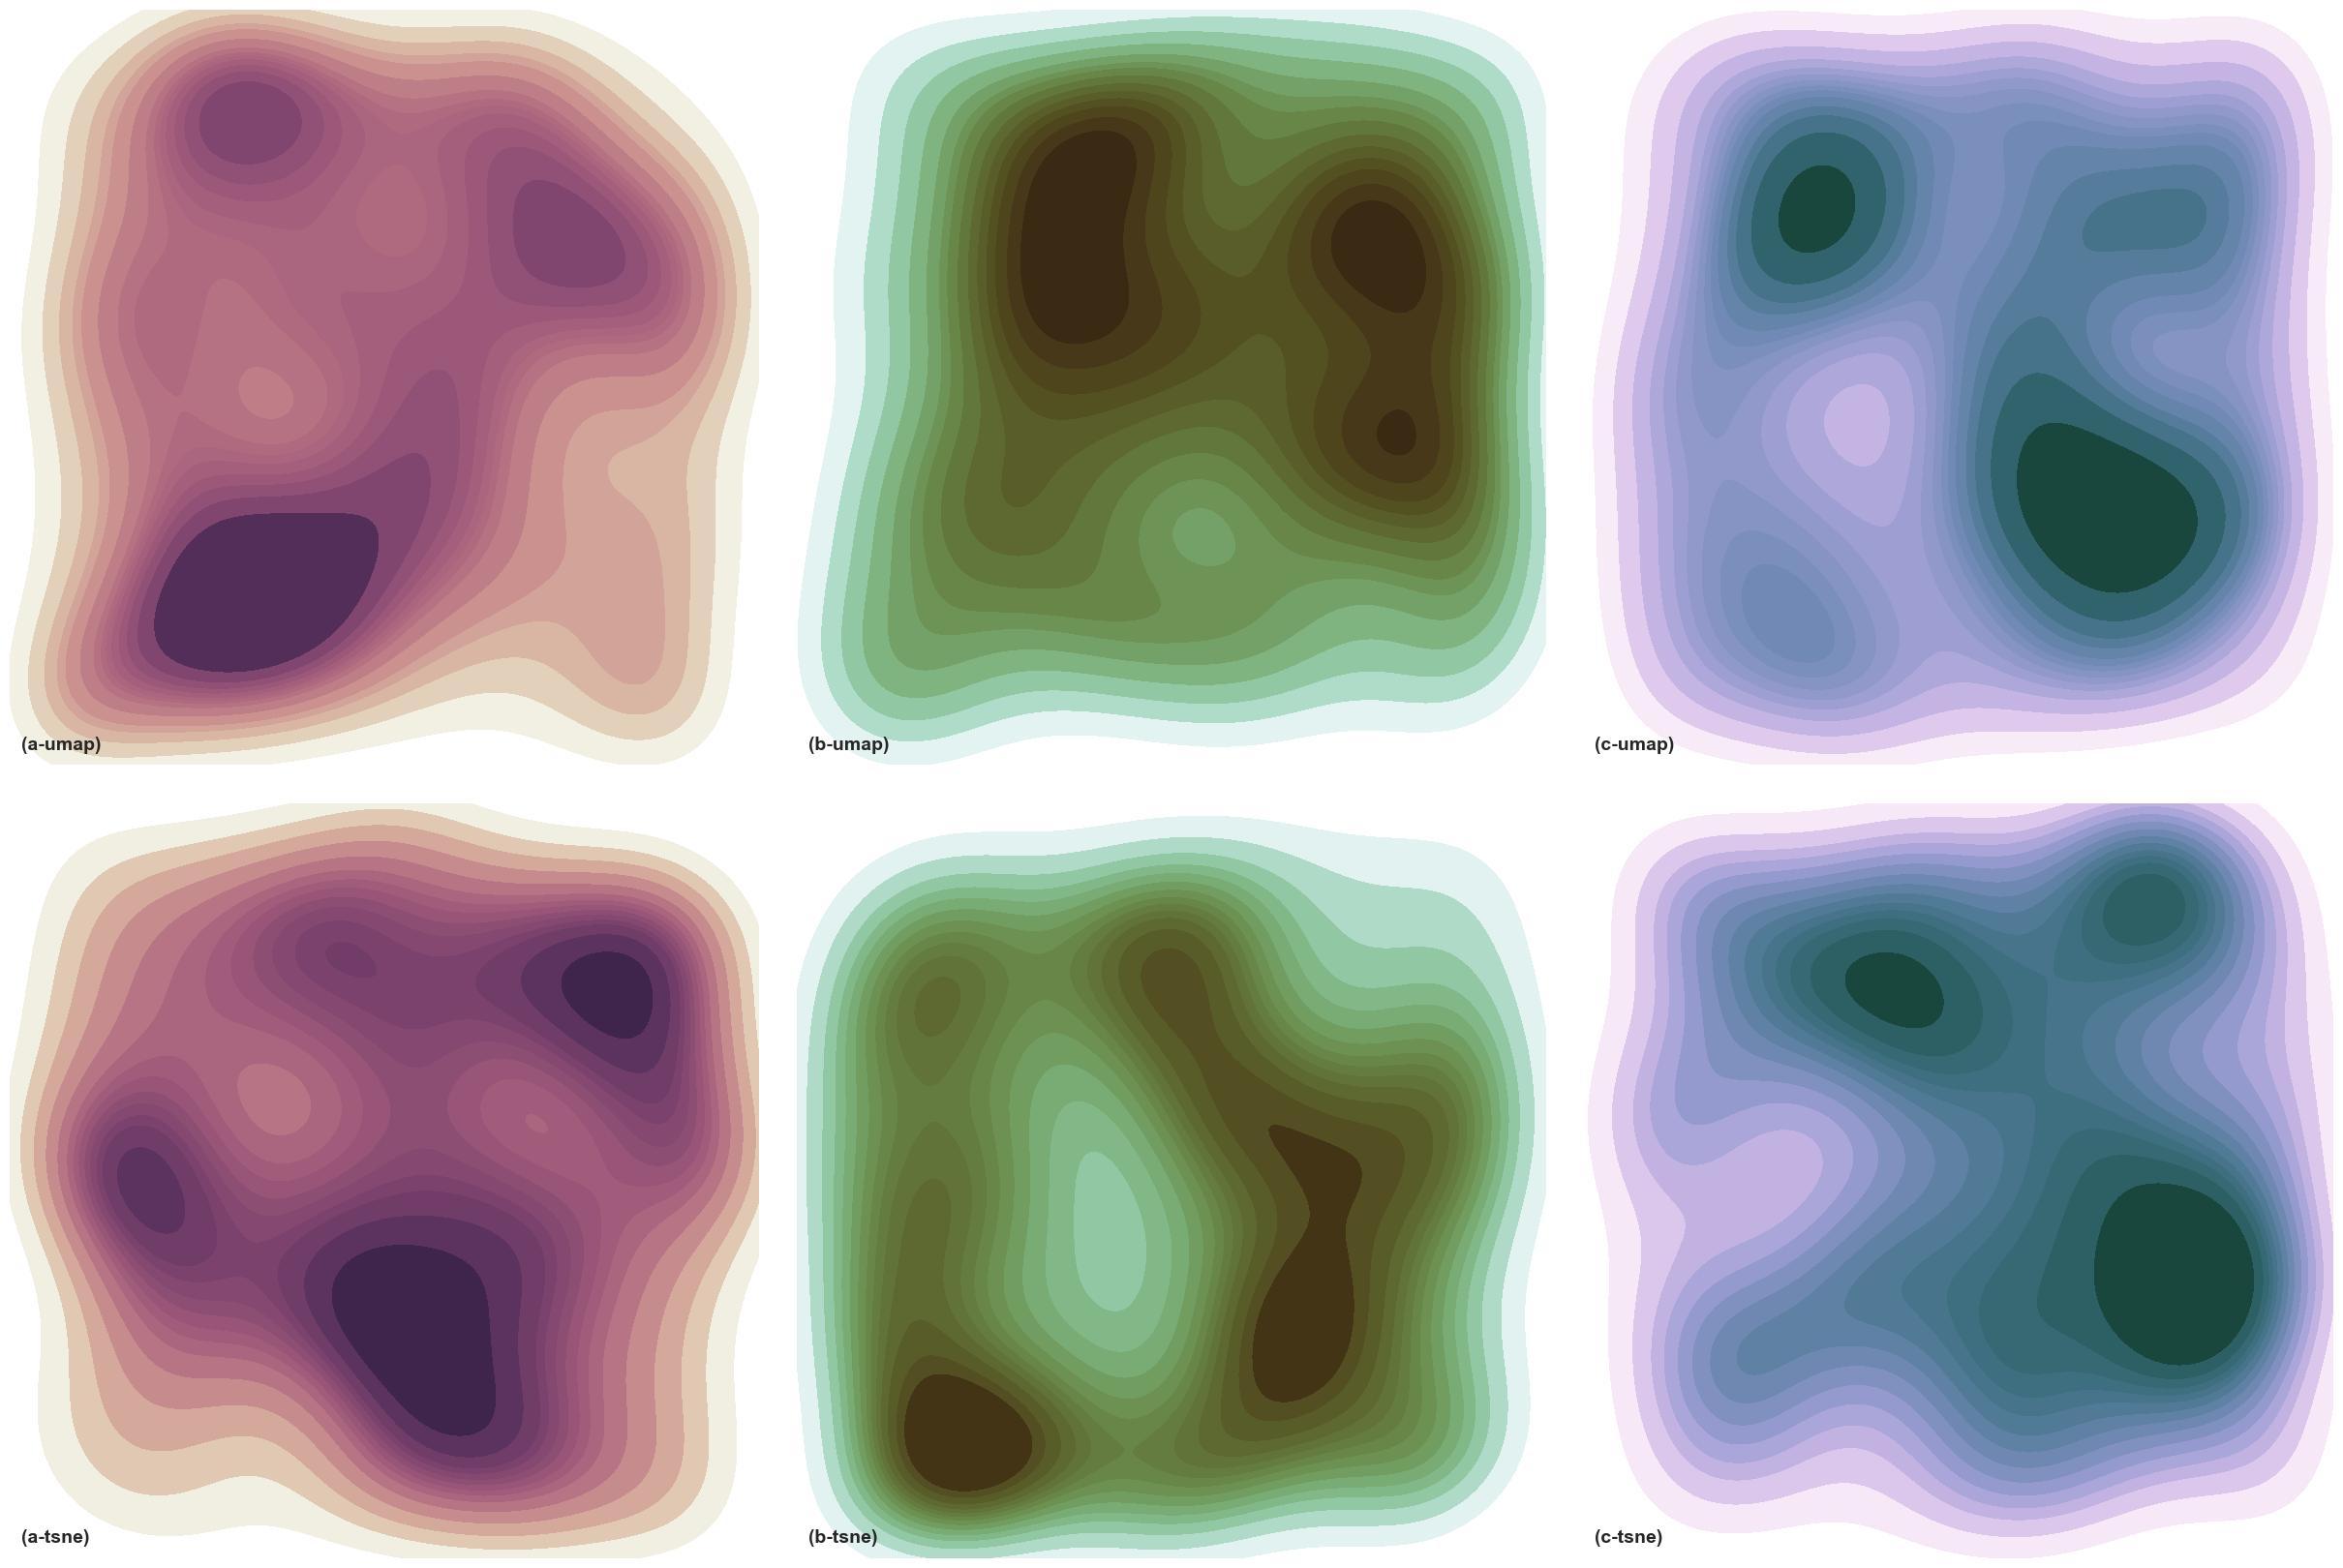

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

img_dir = os.path.join(os.getcwd(), "img")
os.makedirs(img_dir, exist_ok=True)

sns.set_theme(style="white")

# Labels for 6 subplots
labels = ['(a-umap)', '(b-umap)', '(c-umap)', '(a-tsne)', '(b-tsne)', '(c-tsne)']

# Generate demo data compatible with your approach
# Each "dataset" is a dictionary with 'x' and 'y' keys
np.random.seed(50)
teaser_data = []
for _ in range(6):
    teaser_data.append({
        'x': np.random.uniform(-1, 1, 500),
        'y': np.random.uniform(-1, 1, 500)
    })

# 2 rows, 3 columns
f, axes = plt.subplots(2, 3, figsize=(24, 16), sharex=True, sharey=True)
axes = axes.flatten()

# Use 3 distinct cubehelix starts for the first row and repeat for the second
cubehelix_starts = [0, 1.0, 2.0, 0, 1.0, 2.0]

for ax, ds, label, s in zip(axes, teaser_data, labels, cubehelix_starts):
    x = ds['x']
    y = ds['y']
    
    # Cubehelix colormap
    cmap = sns.cubehelix_palette(start=s, rot=0.5, light=1, as_cmap=True)
    
    # KDE plot
    sns.kdeplot(
        x=x, y=y,
        cmap=cmap,
        fill=True,
        clip=(-1.0, 1.0),
        thresh=0.1,
        levels=15,
        ax=ax,
    )
    
    ax.set_axis_off()
    ax.text(-0.97, -0.96, label, fontsize=14, fontweight='bold')

ax.set(xlim=(-1.0, 1.0), ylim=(-1.0, 1.0))
f.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.05, hspace=0.05)

# Generate filename with timestamp
timestamp = datetime.now().strftime("%Y%m%dT%H%M%S")
filename = f"teaser_{timestamp}.pdf"
filepath = os.path.join(img_dir, filename)

# Save as PDF
plt.savefig(filepath, format='pdf', bbox_inches='tight')
print(f"Saved plot to: {filepath}")

plt.show()

